In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
%matplotlib inline

leads = pd.read_csv("../data/raw/olist_marketing_qualified_leads_dataset.csv")
deals = pd.read_csv("../data/raw/olist_closed_deals_dataset.csv")

print(f"Leads shape: {leads.shape}")
print(f"Deals shape: {deals.shape}")

Leads shape: (8000, 4)
Deals shape: (842, 14)


In [3]:
leads.head()

,mql_id,first_contact_date,landing_page_id,origin
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search


In [4]:
deals.head()

,mql_id,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
0,5420aad7fec3549a85876ba1c529bd84,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,cat,NaN,NaN,NaN,reseller,NaN,0.0
1,a555fb36b9368110ede0f043dfc3b9a0,bbb7d7893a450660432ea6652310ebb7,09285259593c61296eef10c734121d5b,d3d1e91a157ea7f90548eef82f1955e3,2018-05-08 20:17:59,car_accessories,industry,eagle,NaN,NaN,NaN,reseller,NaN,0.0
2,327174d3648a2d047e8940d7d15204ca,612170e34b97004b3ba37eae81836b4c,b90f87164b5f8c2cfa5c8572834dbe3f,6565aa9ce3178a5caf6171827af3a9ba,2018-06-05 17:27:23,home_appliances,online_big,cat,NaN,NaN,NaN,reseller,NaN,0.0
3,f5fee8f7da74f4887f5bcae2bafb6dd6,21e1781e36faf92725dde4730a88ca0f,56bf83c4bb35763a51c2baab501b4c67,d3d1e91a157ea7f90548eef82f1955e3,2018-01-17 13:51:03,food_drink,online_small,NaN,NaN,NaN,NaN,reseller,NaN,0.0
4,ffe640179b554e295c167a2f6be528e0,ed8cb7b190ceb6067227478e48cf8dde,4b339f9567d060bcea4f5136b9f5949e,d3d1e91a157ea7f90548eef82f1955e3,2018-07-03 20:17:45,home_appliances,industry,wolf,NaN,NaN,NaN,manufacturer,NaN,0.0


In [5]:
df = pd.merge(leads, deals, on="mql_id", how="left")
print(df.shape)
df.head()

(8000, 17)


,mql_id,first_contact_date,landing_page_id,origin,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,lead_behaviour_profile,has_company,has_gtin,average_stock,business_type,declared_product_catalog_size,declared_monthly_revenue
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,cat,NaN,NaN,NaN,reseller,NaN,0.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   mql_id                         8000 non-null   str    
 1   first_contact_date             8000 non-null   str    
 2   landing_page_id                8000 non-null   str    
 3   origin                         7940 non-null   str    
 4   seller_id                      842 non-null    str    
 5   sdr_id                         842 non-null    str    
 6   sr_id                          842 non-null    str    
 7   won_date                       842 non-null    str    
 8   business_segment               841 non-null    str    
 9   lead_type                      836 non-null    str    
 10  lead_behaviour_profile         665 non-null    str    
 11  has_company                    63 non-null     object 
 12  has_gtin                       64 non-null     object 
 13 

In [7]:
print(len(df.columns))

for col in df.columns:
    print(col)

17
mql_id
first_contact_date
landing_page_id
origin
seller_id
sdr_id
sr_id
won_date
business_segment
lead_type
lead_behaviour_profile
has_company
has_gtin
average_stock
business_type
declared_product_catalog_size
declared_monthly_revenue


In [10]:
print(df.shape)

(8000, 17)


In [11]:
df.head(3).T

,0,1,2
mql_id,dac32acd4db4c29c230538b72f8dd87d,8c18d1de7f67e60dbd64e3c07d7e9d5d,b4bc852d233dfefc5131f593b538befa
first_contact_date,2018-02-01,2017-10-20,2018-03-22
landing_page_id,88740e65d5d6b056e0cda098e1ea6313,007f9098284a86ee80ddeb25d53e0af8,a7982125ff7aa3b2054c6e44f9d28522
origin,social,paid_search,organic_search
seller_id,NaN,NaN,NaN
sdr_id,NaN,NaN,NaN
sr_id,NaN,NaN,NaN
won_date,NaN,NaN,NaN
business_segment,NaN,NaN,NaN
lead_type,NaN,NaN,NaN


In [12]:
df.describe()

,declared_product_catalog_size,declared_monthly_revenue
count,69.000000,8.420000e+02
mean,233.028986,7.337768e+04
std,352.380558,1.744799e+06
min,1.000000,0.000000e+00
25%,30.000000,0.000000e+00
50%,100.000000,0.000000e+00
75%,300.000000,0.000000e+00
max,2000.000000,5.000000e+07


In [15]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)
print(missing_df[missing_df["missing_count"] > 0])

                               missing_count  missing_pct
has_company                             7937        99.21
has_gtin                                7936        99.20
average_stock                           7934        99.18
declared_product_catalog_size           7931        99.14
lead_behaviour_profile                  7335        91.69
business_type                           7168        89.60
lead_type                               7164        89.55
business_segment                        7159        89.49
sr_id                                   7158        89.48
declared_monthly_revenue                7158        89.48
sdr_id                                  7158        89.48
seller_id                               7158        89.48
won_date                                7158        89.48
origin                                    60         0.75


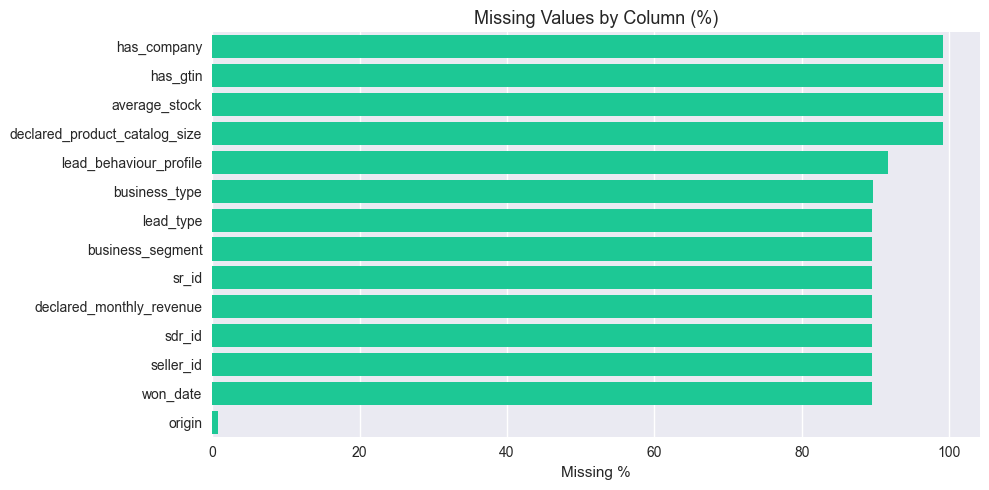

In [16]:
missing_to_plot = missing_df[missing_df["missing_count"] > 0]

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_to_plot["missing_pct"], y=missing_to_plot.index, color="#00e5a0")
plt.title("Missing Values by Column (%)", fontsize=13)
plt.xlabel("Missing %")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [17]:
print(df.duplicated().sum())
print(df["mql_id"].duplicated().sum())

0
0


In [18]:
to_drop = missing_df[missing_df["missing_pct"] > 90].index.tolist()
print("colums to drop (>90% missing):")
for col in to_drop:
    print(col)

colums to drop (>90% missing):
has_company
has_gtin
average_stock
declared_product_catalog_size
lead_behaviour_profile


In [19]:
df["converted"] = df["seller_id"].notnull().astype(int)

print(f"Total Leads:    {len(df):,}")
print(f"Closed Won:     {df['converted'].sum():,}")
print(f"Not Converted:  {(df['converted'] == 0).sum():,}")
print(f"Conversion Rate: {df['converted'].mean()*100:.2f}%")


Total Leads:    8,000
Closed Won:     842
Not Converted:  7,158
Conversion Rate: 10.53%


In [20]:
funnel = pd.DataFrame({
    "stage": ["Visitors/Leads", "Closed Won"],
    "count": [len(df), df["converted"].sum()]
})

funnel["conversion_from_total"] = (funnel["count"] / len(df) * 100).round(2)
funnel["drop_off"] = funnel["count"].diff(-1).fillna(0).astype(int)

print(funnel.to_string(index=False))

         stage  count  conversion_from_total  drop_off
Visitors/Leads   8000                 100.00      7158
    Closed Won    842                  10.52         0


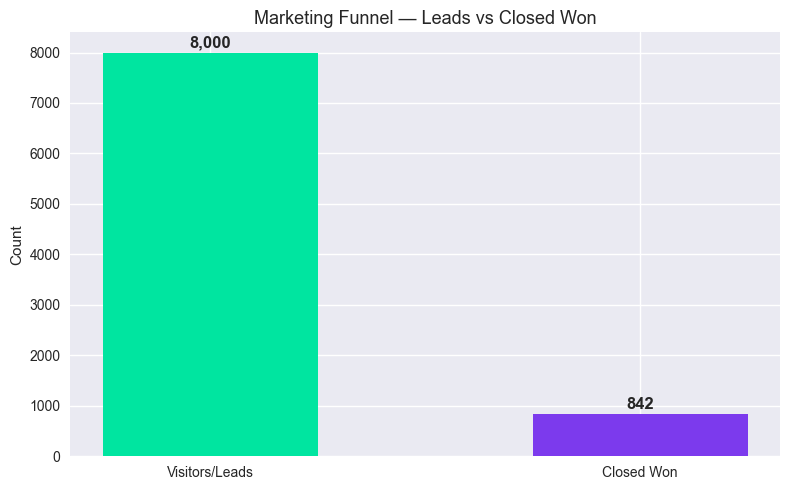

In [21]:
plt.figure(figsize=(8, 5))
colors = ["#00e5a0", "#7c3aed"]
bars = plt.bar(funnel["stage"], funnel["count"], color=colors, width=0.5)

for bar, count in zip(bars, funnel["count"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f"{count:,}", ha="center", fontsize=12, fontweight="bold")

plt.title("Marketing Funnel — Leads vs Closed Won", fontsize=13)
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [22]:
print(df["origin"].value_counts())

origin
organic_search       2296
paid_search          1586
social               1350
unknown              1099
direct_traffic        499
email                 493
referral              284
other                 150
display               118
other_publicities      65
Name: count, dtype: int64


In [23]:
channel_analysis = df.groupby("origin").agg(
    total_leads=("mql_id", "count"),
    closed_won=("converted", "sum")
).reset_index()

channel_analysis["conversion_rate"] = (
    channel_analysis["closed_won"] / channel_analysis["total_leads"] * 100
).round(2)

channel_analysis = channel_analysis.sort_values("conversion_rate", ascending=False)

print(channel_analysis.to_string(index=False))

           origin  total_leads  closed_won  conversion_rate
          unknown         1099         179            16.29
      paid_search         1586         195            12.30
   organic_search         2296         271            11.80
   direct_traffic          499          56            11.22
         referral          284          24             8.45
           social         1350          75             5.56
          display          118           6             5.08
other_publicities           65           3             4.62
            email          493          15             3.04
            other          150           4             2.67


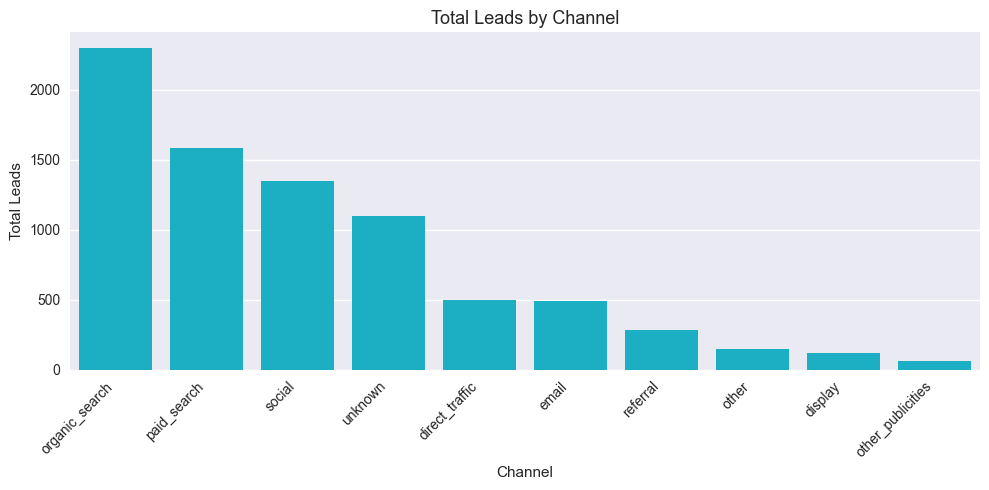

In [24]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=channel_analysis.sort_values("total_leads", ascending=False),
    x="origin",
    y="total_leads",
    color="#00c4e0"
)
plt.title("Total Leads by Channel", fontsize=13)
plt.xlabel("Channel")
plt.ylabel("Total Leads")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

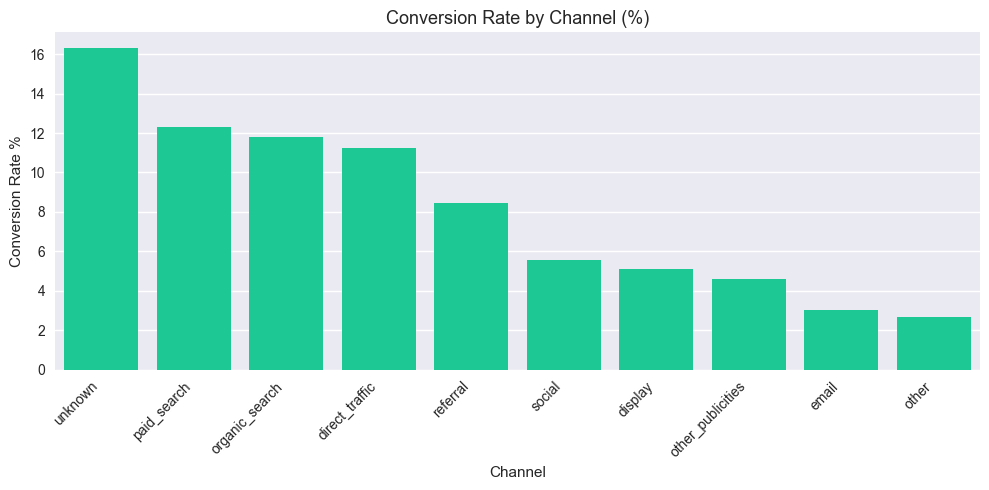

In [25]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=channel_analysis.sort_values("conversion_rate", ascending=False),
    x="origin",
    y="conversion_rate",
    color="#00e5a0"
)
plt.title("Conversion Rate by Channel (%)", fontsize=13)
plt.xlabel("Channel")
plt.ylabel("Conversion Rate %")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10524\791863818.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_10524\791863818.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")


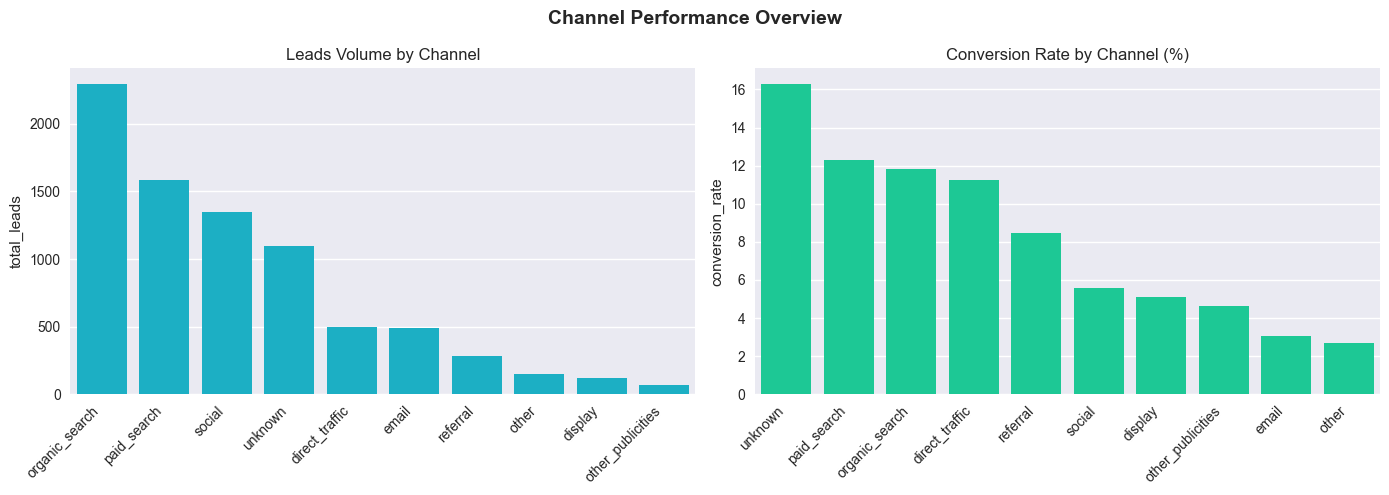

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.barplot(
    data=channel_analysis.sort_values("total_leads", ascending=False),
    x="origin", y="total_leads",
    color="#00c4e0", ax=axes[0]
)
axes[0].set_title("Leads Volume by Channel")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
axes[0].set_xlabel("")


sns.barplot(
    data=channel_analysis.sort_values("conversion_rate", ascending=False),
    x="origin", y="conversion_rate",
    color="#00e5a0", ax=axes[1]
)
axes[1].set_title("Conversion Rate by Channel (%)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")
axes[1].set_xlabel("")

plt.suptitle("Channel Performance Overview", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [27]:
best = channel_analysis.iloc[0]
worst = channel_analysis.iloc[-1]

print("🏆 Best converting channel:")
print(f"   {best['origin']} — {best['conversion_rate']}% ({best['closed_won']} won / {best['total_leads']} leads)")

print("\n⚠️  Worst converting channel:")
print(f"   {worst['origin']} — {worst['conversion_rate']}% ({worst['closed_won']} won / {worst['total_leads']} leads)")

🏆 Best converting channel:
   unknown — 16.29% (179 won / 1099 leads)

⚠️  Worst converting channel:
   other — 2.67% (4 won / 150 leads)


In [28]:
df["first_contact_date"] = pd.to_datetime(df["first_contact_date"])
df["won_date"] = pd.to_datetime(df["won_date"])

print("Date range:")
print(f"  First contact: {df['first_contact_date'].min()} → {df['first_contact_date'].max()}")
print(f"  Won date:      {df['won_date'].min()} → {df['won_date'].max()}")

Date range:
  First contact: 2017-06-14 00:00:00 → 2018-05-31 00:00:00
  Won date:      2017-12-05 02:00:00 → 2018-11-14 18:04:19


In [29]:
df["month"] = df["first_contact_date"].dt.to_period("M")

monthly_leads = df.groupby("month").agg(
    total_leads=("mql_id", "count"),
    closed_won=("converted", "sum")
).reset_index()

monthly_leads["conversion_rate"] = (
    monthly_leads["closed_won"] / monthly_leads["total_leads"] * 100
).round(2)

print(monthly_leads.to_string(index=False))

  month  total_leads  closed_won  conversion_rate
2017-06            4           0             0.00
2017-07          239           2             0.84
2017-08          386           9             2.33
2017-09          312           7             2.24
2017-10          416          14             3.37
2017-11          445          18             4.04
2017-12          200          11             5.50
2018-01         1141         152            13.32
2018-02         1028         149            14.49
2018-03         1174         167            14.22
2018-04         1352         183            13.54
2018-05         1303         130             9.98


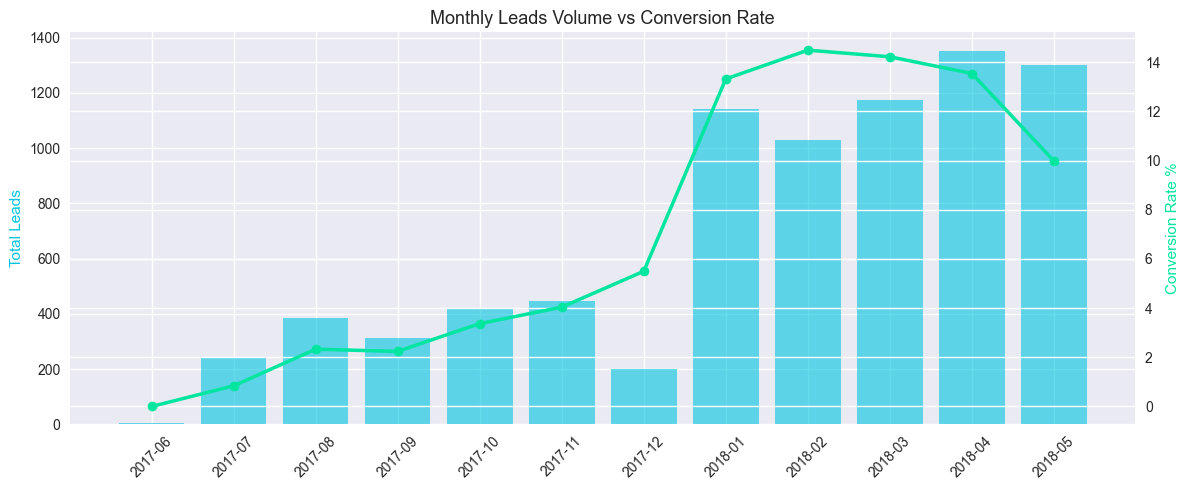

In [31]:
fig, ax1 = plt.subplots(figsize=(12, 5))

months = monthly_leads["month"].astype(str)


ax1.bar(months, monthly_leads["total_leads"], color="#00c4e0", alpha=0.6, label="Total Leads")
ax1.set_ylabel("Total Leads", color="#00c4e0")
ax1.tick_params(axis="x", rotation=45)


ax2 = ax1.twinx()
ax2.plot(months, monthly_leads["conversion_rate"], color="#00e5a0",
         linewidth=2.5, marker="o", label="CVR %")
ax2.set_ylabel("Conversion Rate %", color="#00e5a0")

plt.title("Monthly Leads Volume vs Conversion Rate", fontsize=13)
fig.tight_layout()
plt.show()

In [32]:
won_df = df[df["converted"] == 1].copy()
won_df["days_to_close"] = (won_df["won_date"] - won_df["first_contact_date"]).dt.days

print(f"Average days to close:  {won_df['days_to_close'].mean():.0f} days")
print(f"Median days to close:   {won_df['days_to_close'].median():.0f} days")
print(f"Fastest close:          {won_df['days_to_close'].min()} days")
print(f"Slowest close:          {won_df['days_to_close'].max()} days")

Average days to close:  48 days
Median days to close:   14 days
Fastest close:          -2 days
Slowest close:          427 days


In [33]:
days_by_channel = won_df.groupby("origin")["days_to_close"].agg(
    avg_days="mean",
    median_days="median",
    count="count"
).round(1).sort_values("avg_days")

print(days_by_channel.to_string())

                   avg_days  median_days  count
origin                                         
display                10.3          8.5      6
other                  15.2          9.0      4
direct_traffic         31.1         10.0     56
referral               32.5         18.5     24
other_publicities      39.3         35.0      3
unknown                41.3         11.0    179
organic_search         50.0         14.0    271
email                  52.2         21.0     15
paid_search            56.6         15.0    195
social                 61.0         30.0     75


In [34]:

anomalies = won_df[won_df["days_to_close"] < 0]
print(f"Records with negative days to close: {len(anomalies)}")
print(anomalies[["mql_id", "first_contact_date", "won_date", "days_to_close"]])

Records with negative days to close: 1
                                mql_id first_contact_date            won_date  \
6357  b91cf8812365f50ff4bda4bcd6206b05         2018-03-08 2018-03-06 19:38:55   

      days_to_close  
6357             -2  


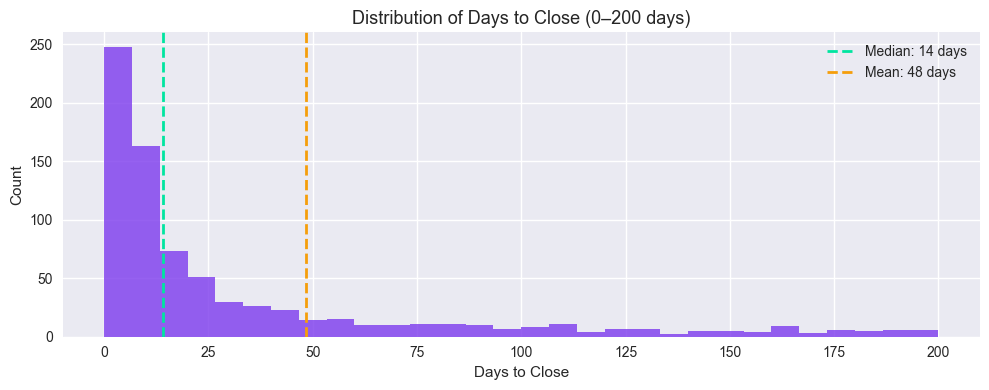

In [35]:
plt.figure(figsize=(10, 4))

clean_days = won_df[won_df["days_to_close"].between(0, 200)]["days_to_close"]

plt.hist(clean_days, bins=30, color="#7c3aed", edgecolor="none", alpha=0.8)
plt.axvline(won_df["days_to_close"].median(), color="#00e5a0",
            linewidth=2, linestyle="--", label=f"Median: {won_df['days_to_close'].median():.0f} days")
plt.axvline(won_df["days_to_close"].mean(), color="#f59e0b",
            linewidth=2, linestyle="--", label=f"Mean: {won_df['days_to_close'].mean():.0f} days")

plt.title("Distribution of Days to Close (0–200 days)", fontsize=13)
plt.xlabel("Days to Close")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

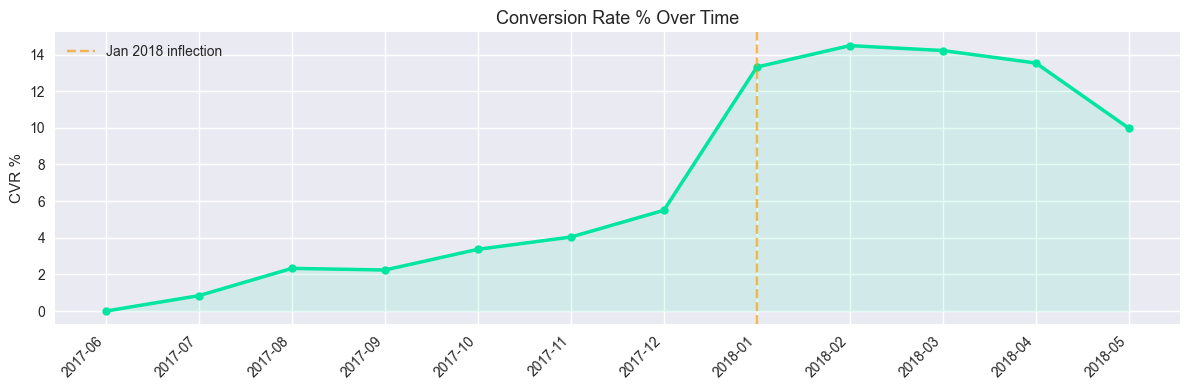

In [36]:
plt.figure(figsize=(12, 4))
months = monthly_leads["month"].astype(str)

plt.plot(months, monthly_leads["conversion_rate"],
         color="#00e5a0", linewidth=2.5, marker="o", markersize=6)

plt.axvline(x="2018-01", color="#f59e0b", linestyle="--", alpha=0.7, label="Jan 2018 inflection")

plt.fill_between(range(len(months)), monthly_leads["conversion_rate"],
                 alpha=0.1, color="#00e5a0")

plt.xticks(range(len(months)), months, rotation=45, ha="right")
plt.title("Conversion Rate % Over Time", fontsize=13)
plt.ylabel("CVR %")
plt.legend()
plt.tight_layout()
plt.show()